
# Lab 3: PDE with FDM

Bernardo Alejandro Mendoza Montes - 1001363373

#### **Exercise 1**: Finite-differences method (FDM) with tolerance **Jacobi method**.


Laplace's equation in the dominio $0\leq x \leq L$ and $0\leq y \leq L$ with Dirichlet's boundary conditions:

* $u(x,0)=V(x)=f(x)\to V_0=100$ V
* $u(0,y)=0$
* $u(L,y)=0$
* $u(x,L)=0$

1. Solve the Laplace's equation using finite differences for an specific tolerance ($10^{-6}<\text{tol}<10^{-1}$). Do a plot of the field $u(x,y)$ for $\text{tol}=10^{-3}$. Explain in your own words the strategy followed.
2. Compare with the **Fourier serie**. How many terms in the Fourier serie are necessary to get a $\text{tol}=10^{-4}$?

#### **Exercise 2**: FDM for oppen boundaries (bonus!)

1. Solve **analytically** the Laplace's equation for $u(x,y)$ in the dominio $0\leq x \leq L$ and $0\leq y < \infty $, with Dirichlet's boundary conditions:

* $u(x,0)=V(x)=f(x) = u_0\sin(2\pi x/L)e^{-2\pi y/L}$
* $u(0,y)=0$
* $u(L,y)=0$
* $u(x,\infty)=0$,

Explain in your own words the strategy followed and write the analytical result.


1. Solve **numerically** the Laplace's equation, set the lenght $L=N\Delta = 100$ and $\Delta=1$ and $u_0=100$.

<img src="https://github.com/anferivera/Fisica_Computacional_1/raw/main/Sesiones/PDE/figures/Laplace_df_4.png" width="200" height="300" />

## Electric filed and potential in a parallel-plate capacitor

#### **Exercise 3**

To find the potential generated by a capacitor  of two rectangular plates of width $d$ is challenging (see figure). In general, we can do some approximation based in infinite plates to get an intuition of the solution. In this approximation we have:


\begin{equation}
|\vec{E}| \approx \dfrac{\sigma}{2\epsilon_0}, \text{inside}\,,
\end{equation}

\begin{equation}
|\vec{E}| \approx 0, \text{  outside}\,.
\end{equation}


However, we know that the potential $\phi$ and the electric field $\vec{E}$ fulfill the Laplace's equation $\nabla^2\phi = 0$ in the region around the plates (where $\rho=0$).

1. Use finite differences to solve the Laplace's equation in the neigborhood of this capacitor. Use the imshow or the contour function to plot the potential.

2. Compute numerically the electric field (use finite difference method).

<img src="https://github.com/anferivera/Fisica_Computacional_1/raw/main/Sesiones/PDE/figures/Laplace_df_capacitor.png" alt="drawing" width="600"/>

# Ejercicio 1: diferencias finitas dentro de un intervalo de tolerancia.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [6]:
def Laplace2D_FDM_tol(V_ini, tol=1e-5, max_iter=10000):

    Nmax = V_ini.shape[0]
    V = V_ini.copy()

    error = float('inf')  # Definimos el error como un número "infinito" para que se haga el calculo al menos 1 vez
    iter_count = 0        # Contador

    while error > tol and iter_count < max_iter:
        error = 0.0  # Reiniciamos el error máximo para la iteración actual

        for i in range(1, Nmax - 1):
            for j in range(1, Nmax - 1):
                V_viejo = V[i, j]

                V[i, j] = 0.25 * (V[i+1, j] + V[i-1, j] + V[i, j+1] + V[i, j-1])

                # Calculamos la diferencia absoluta entre el valor nuevo y el anterior
                diff = abs(V[i, j] - V_viejo)

                # Guardamos la máxima diferencia encontrada en toda la malla
                if diff > error:
                    error = diff

        iter_count += 1

    print(f"Convergencia alcanzada en {iter_count} iteraciones con un error de {error:.2e}")
    return V

def grid(V_ini,x,y):
  'to compute x,y,z'
  V = V_ini.copy()
  X, Y = np.meshgrid(x,y)
  Z = V[X,Y] #filed value
  #return grid
  return X,Y,Z

In [16]:
Nmax, tol = 100, 1e-3
x = np.arange(0, Nmax)
y = np.arange(0, Nmax)

V_ini = np.zeros((Nmax, Nmax), float) # grid in 0V.
for k in range(0, Nmax):
  V_ini[k,0] = 100. # Condición de frontera

V = Laplace2D_FDM_tol(V_ini, tol)
X,Y,Z = grid(V,x,y)

Convergencia alcanzada en 3660 iteraciones con un error de 1.00e-03


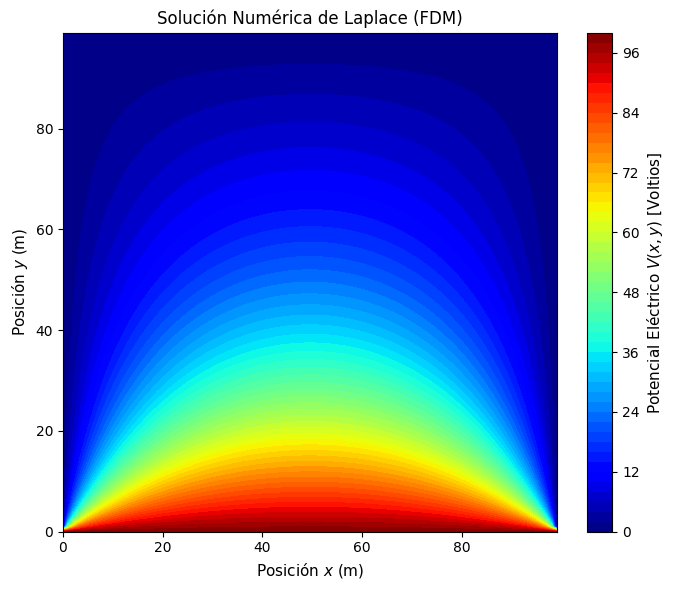

In [26]:
plt.figure(figsize=(7, 6))
mapa = plt.contourf(X, Y, Z, levels=50, cmap='jet')

cbar = plt.colorbar(mapa)
cbar.set_label('Potencial Eléctrico $V(x,y)$ [Voltios]', fontsize=11)

plt.title('Solución Numérica de Laplace (FDM)', fontsize=12)
plt.xlabel('Posición $x$ (m)', fontsize=11)
plt.ylabel('Posición $y$ (m)', fontsize=11)

plt.tight_layout()
plt.show()

In [3]:
def serie_n(x, y, n, L, v0):
    """
    Término n-ésimo reformulado con exponenciales negativas
    para evitar overflow numérico con np.sinh.
    """
    exp1 = np.exp(-n * np.pi * y / L)
    exp2 = np.exp(-n * np.pi * (2 * L - y) / L)
    exp_den = np.exp(-2 * n * np.pi)

    ratio = (exp1 - exp2) / (1.0 - exp_den)
    return (4 * v0 / (n * np.pi)) * np.sin(n * np.pi * x / L) * ratio


def Laplace2D_Exacta_tol(x, y, L, v0, tol=1e-3, max_terms=1000):
    X, Y = np.meshgrid(x, y)
    V_total = np.zeros_like(X, dtype=float)

    n = 1

    # Identificamos el índice a partir del cual y > 0.01 L
    # para evitar medir la frontera discontinua exacta
    idx_y_interior = np.argmax(y > 0.01 * L)
    if idx_y_interior == 0:
        idx_y_interior = 1

    while n <= max_terms:
        # 1. Calcular el término n-ésimo
        V_n = serie_n(X, Y, n, L, v0)

        # 2. Acumular la solución
        V_total += V_n

        # 3. Medir el error en el interior (omitimos bordes laterales y el área pegada a y = 0)
        error = np.max(np.abs(V_n[idx_y_interior:-1, 1:-1]))

        # 4. Verificación de parada
        if error <= tol:
            print(f"Fourier convergido exitosamente en n = {n} términos con un error de {error:.2e}")
            break

        n += 2

    if n > max_terms:
        print(f"Alcanzado el límite máximo (n = {n-2}) con error = {error:.2e}")

    return V_total

In [4]:
tol = 1.00e-04  # Tolerancia deseada
v0 = 100        # Valor del campo en la pared
L = 100           # Longitud del dominio

rangox = np.linspace(0, L, 1000)
rangoy = np.linspace(0, L, 1000)

V_exacta = Laplace2D_Exacta_tol(rangox, rangoy, L, v0, tol)

Fourier convergido exitosamente en n = 271 términos con un error de 9.35e-05


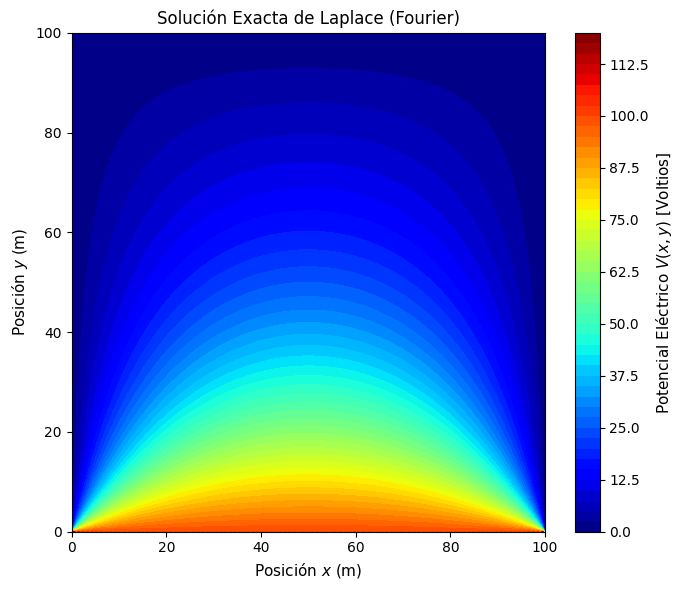

In [25]:
plt.figure(figsize=(7, 6))
mapa = plt.contourf(rangox, rangoy, V_exacta, levels=50, cmap='jet')

cbar = plt.colorbar(mapa)
cbar.set_label('Potencial Eléctrico $V(x,y)$ [Voltios]', fontsize=11)

plt.title('Solución Exacta de Laplace (Fourier)', fontsize=12)
plt.xlabel('Posición $x$ (m)', fontsize=11)
plt.ylabel('Posición $y$ (m)', fontsize=11)

plt.tight_layout()
plt.show()

# Ejercicio 3: Capacitor de Placas Paralelas

In [9]:
# Configuración del Dominio y Malla

Nx, Ny = 100, 100      # Nodos en la rejilla (100x100)
L = 1.0                # Tamaño del dominio
tol = 1e-4             # Tolerancia de convergencia
max_iter = 10000
V0 = 100.0

# Posiciones de las placas en la malla

x_placa1 = int(0.35 * Nx) # Placa 1 (Izquierda): x = 35%, desde y = 25% hasta y = 75%
x_placa2 = int(0.65 * Nx) # Placa 2 (Derecha):   x = 65%, desde y = 25% hasta y = 75%
y_min = int(0.25 * Ny)
y_max = int(0.75 * Ny)

# Matriz inicial de potencial

V = np.zeros((Nx, Ny), dtype=float)

# Máscara booleana para identificar los nodos que pertenecen a las placas
# ( True = Es una placa fija, False = Es aire/espacio libre )
placas_mask = np.zeros((Ny, Nx), dtype=bool)


V[y_min:y_max, x_placa1] = +V0 / 2.0   # Placa Positiva (+50V)
V[y_min:y_max, x_placa2] = -V0 / 2.0   # Placa Negativa (-50V)

placas_mask[y_min:y_max, x_placa1] = True
placas_mask[y_min:y_max, x_placa2] = True

In [10]:
# Algoritmo para Diferencias Finitas

error = float('inf')
iter_count = 0

while error > tol and iter_count < max_iter:
    error = 0.0
    for i in range(1, Ny - 1):
        for j in range(1, Nx - 1):
            # Si el nodo es parte de alguna placa, NO se actualiza
            if placas_mask[i, j]:
                continue

            V_viejo = V[i, j]
            # Stencil de 5 puntos para la ecuación de Laplace
            V[i, j] = 0.25 * (V[i+1, j] + V[i-1, j] + V[i, j+1] + V[i, j-1])

            diff = abs(V[i, j] - V_viejo)
            if diff > error:
                error = diff

    iter_count += 1

print(f"Capacitor resuelto en {iter_count} iteraciones (error = {error:.2e})")

Capacitor resuelto en 1652 iteraciones (error = 1.00e-04)


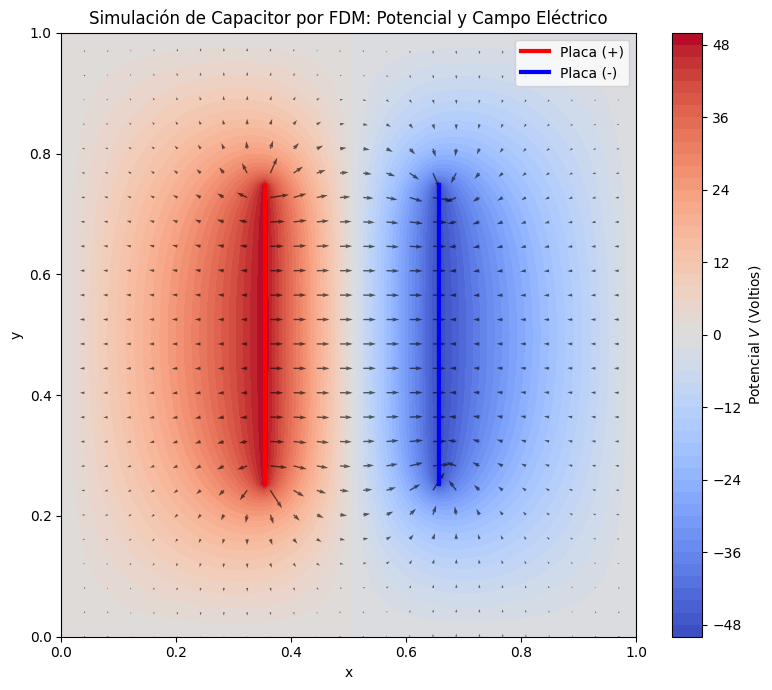

In [12]:
# Cálculo del Campo Eléctrico E = -grad(V)

Ey, Ex = np.gradient(-V)  # Gradiente numérico en Y y X

# Graficación

x = np.linspace(0, L, Nx)
y = np.linspace(0, L, Ny)
X, Y = np.meshgrid(x, y)

plt.figure(figsize=(8, 7))

mapa = plt.contourf(X, Y, V, 50, cmap='coolwarm')
plt.colorbar(mapa, label='Potencial $V$ (Voltios)')

# Dibujar las flechas del Campo Eléctrico (submuestreadas para legibilidad)
step = 4
plt.quiver(X[::step, ::step], Y[::step, ::step],
           Ex[::step, ::step], Ey[::step, ::step],
           color='black', alpha=0.6, scale=150)

# Resaltar las placas en el gráfico
plt.plot([x[x_placa1]]*2, [y[y_min], y[y_max-1]], color='red', linewidth=3, label='Placa (+)')
plt.plot([x[x_placa2]]*2, [y[y_min], y[y_max-1]], color='blue', linewidth=3, label='Placa (-)')

plt.title('Simulación de Capacitor por FDM: Potencial y Campo Eléctrico')
plt.xlabel('x')
plt.ylabel('y')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()